In [85]:
# Importarea bibliotecilor
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [86]:
df=pd.read_csv("electricity_cost_dataset.csv")

In [87]:
df.head()

,site area,structure type,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site area             10000 non-null  int64  
 1   structure type        10000 non-null  object 
 2   water consumption     10000 non-null  float64
 3   recycling rate        10000 non-null  int64  
 4   utilisation rate      10000 non-null  int64  
 5   air qality index      10000 non-null  int64  
 6   issue reolution time  10000 non-null  int64  
 7   resident count        10000 non-null  int64  
 8   electricity cost      10000 non-null  float64
dtypes: float64(2), int64(6), object(1)
memory usage: 703.3+ KB


In [89]:
df.describe()

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2757.775100,3494.057100,49.598000,64.842200,99.468600,36.402600,85.573100,2837.845000
std,1293.059959,2076.181117,23.430141,20.432965,58.014526,20.623905,107.876179,1106.997441
min,501.000000,1000.000000,10.000000,30.000000,0.000000,1.000000,0.000000,500.000000
25%,1624.000000,1779.000000,29.750000,47.000000,49.000000,19.000000,0.000000,1954.000000
50%,2773.500000,3047.500000,49.000000,65.000000,100.000000,36.000000,39.000000,2760.000000
75%,3874.000000,4811.000000,70.000000,83.000000,150.000000,54.000000,142.000000,3632.000000
max,5000.000000,10894.000000,90.000000,100.000000,200.000000,72.000000,489.000000,6446.000000


In [90]:
df.notna().count()

site area               10000
structure type          10000
water consumption       10000
recycling rate          10000
utilisation rate        10000
air qality index        10000
issue reolution time    10000
resident count          10000
electricity cost        10000
dtype: int64

In [91]:
df.nunique()

site area               3992
structure type             4
water consumption       4932
recycling rate            81
utilisation rate          71
air qality index         201
issue reolution time      72
resident count           455
electricity cost        3909
dtype: int64

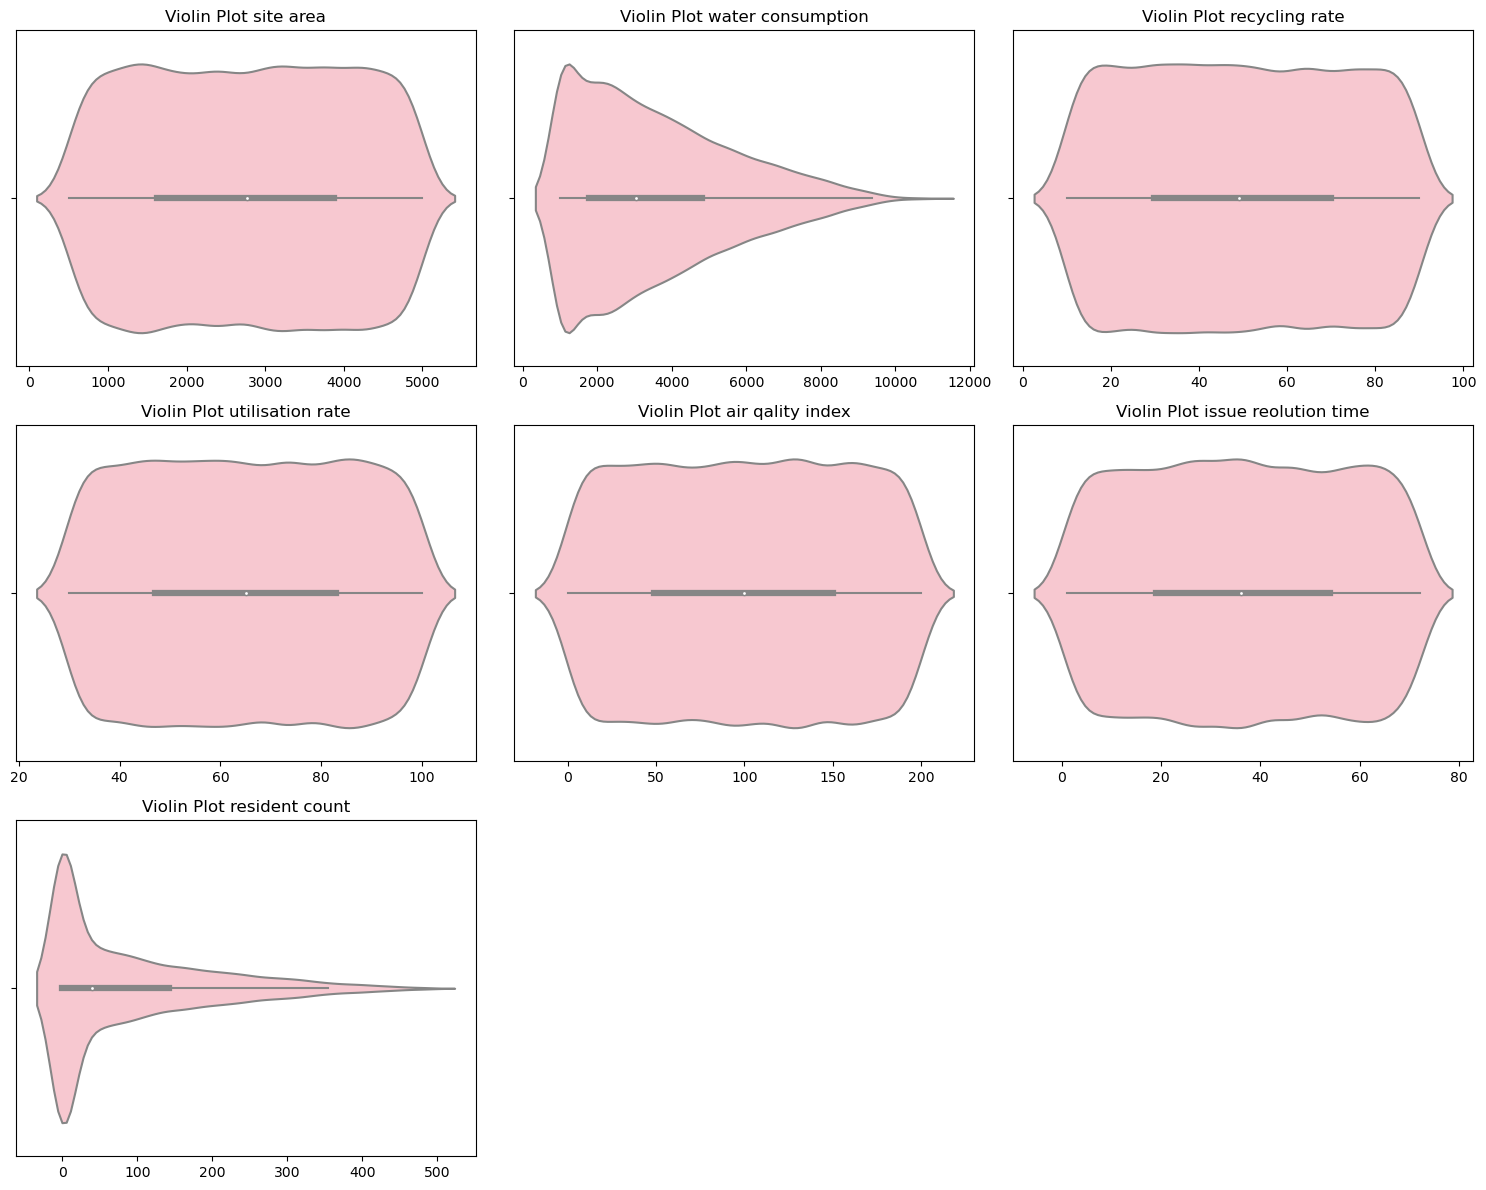

In [92]:
# Selectare coloanele numerice
df_plot=df.drop('electricity cost', axis=1)
num_cols = df_plot.select_dtypes(include=[np.number]).columns

# Setare subploturi
n_cols = 3  # număr de coloane în figură
n_rows = int(np.ceil(len(num_cols) / n_cols))  # calculăm rândurile necesare
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()  # flatten pentru iterație ușoară

# Creare violin plot pentru fiecare coloană numerică
for i, col in enumerate(num_cols):
    sns.violinplot(x=df_plot[col], ax=axes[i], color='pink')
    axes[i].set_title(f"Violin Plot {col}")
    axes[i].set_xlabel("")  # eliminăm label-ul pentru claritate

# Ascunderesubploturile goale
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

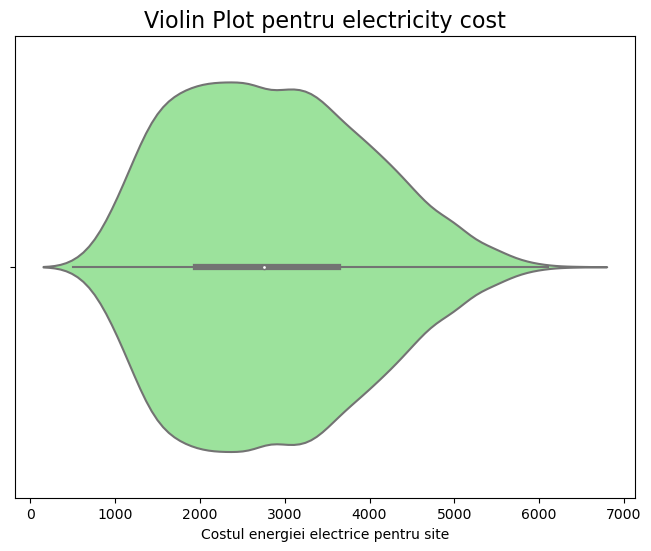

In [93]:
# Creare violin plot pentru MEDV
plt.figure(figsize=(8,6))
sns.violinplot(x=df['electricity cost'], color='lightgreen')

# Adăugare titlu și etichetă pe axa x
plt.title("Violin Plot pentru electricity cost", fontsize=16)
plt.xlabel("Costul energiei electrice pentru site")

plt.show()

In [94]:
df_copy=df.copy()

In [95]:
df_copy.drop('structure type', axis=1)

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,2519.0,69,52,188,1,72,1420.0
1,4272,2324.0,50,76,165,65,261,3298.0
2,3592,2701.0,20,94,198,39,117,3115.0
3,966,1000.0,13,60,74,3,35,1575.0
4,4926,5990.0,23,65,32,57,185,4301.0
...,...,...,...,...,...,...,...,...
9995,708,1365.0,76,77,22,23,0,885.0
9996,2960,3332.0,22,72,100,47,54,3081.0
9997,3942,2427.0,61,43,48,49,0,3325.0
9998,3211,4639.0,72,73,105,55,0,2892.0


In [96]:
df_copy.corr(numeric_only=True)

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
site area,1.000000,0.745372,0.006786,0.019681,-0.003770,0.007520,0.360160,0.874376
water consumption,0.745372,1.000000,0.006977,0.008711,0.000929,0.007786,0.281256,0.698775
recycling rate,0.006786,0.006977,1.000000,-0.022350,-0.011125,-0.005641,-0.008540,-0.012536
utilisation rate,0.019681,0.008711,-0.022350,1.000000,-0.008747,-0.000795,0.012424,0.207215
air qality index,-0.003770,0.000929,-0.011125,-0.008747,1.000000,-0.027277,0.013728,0.017376
issue reolution time,0.007520,0.007786,-0.005641,-0.000795,-0.027277,1.000000,-0.014663,0.042325
resident count,0.360160,0.281256,-0.008540,0.012424,0.013728,-0.014663,1.000000,0.361609
electricity cost,0.874376,0.698775,-0.012536,0.207215,0.017376,0.042325,0.361609,1.000000


                      site area  water consumption  recycling rate  \
site area                  1.00               0.75            0.01   
water consumption          0.75               1.00            0.01   
recycling rate             0.01               0.01            1.00   
utilisation rate           0.02               0.01           -0.02   
air qality index          -0.00               0.00           -0.01   
issue reolution time       0.01               0.01           -0.01   
resident count             0.36               0.28           -0.01   
electricity cost           0.87               0.70           -0.01   

                      utilisation rate  air qality index  \
site area                         0.02             -0.00   
water consumption                 0.01              0.00   
recycling rate                   -0.02             -0.01   
utilisation rate                  1.00             -0.01   
air qality index                 -0.01              1.00   
issue reo

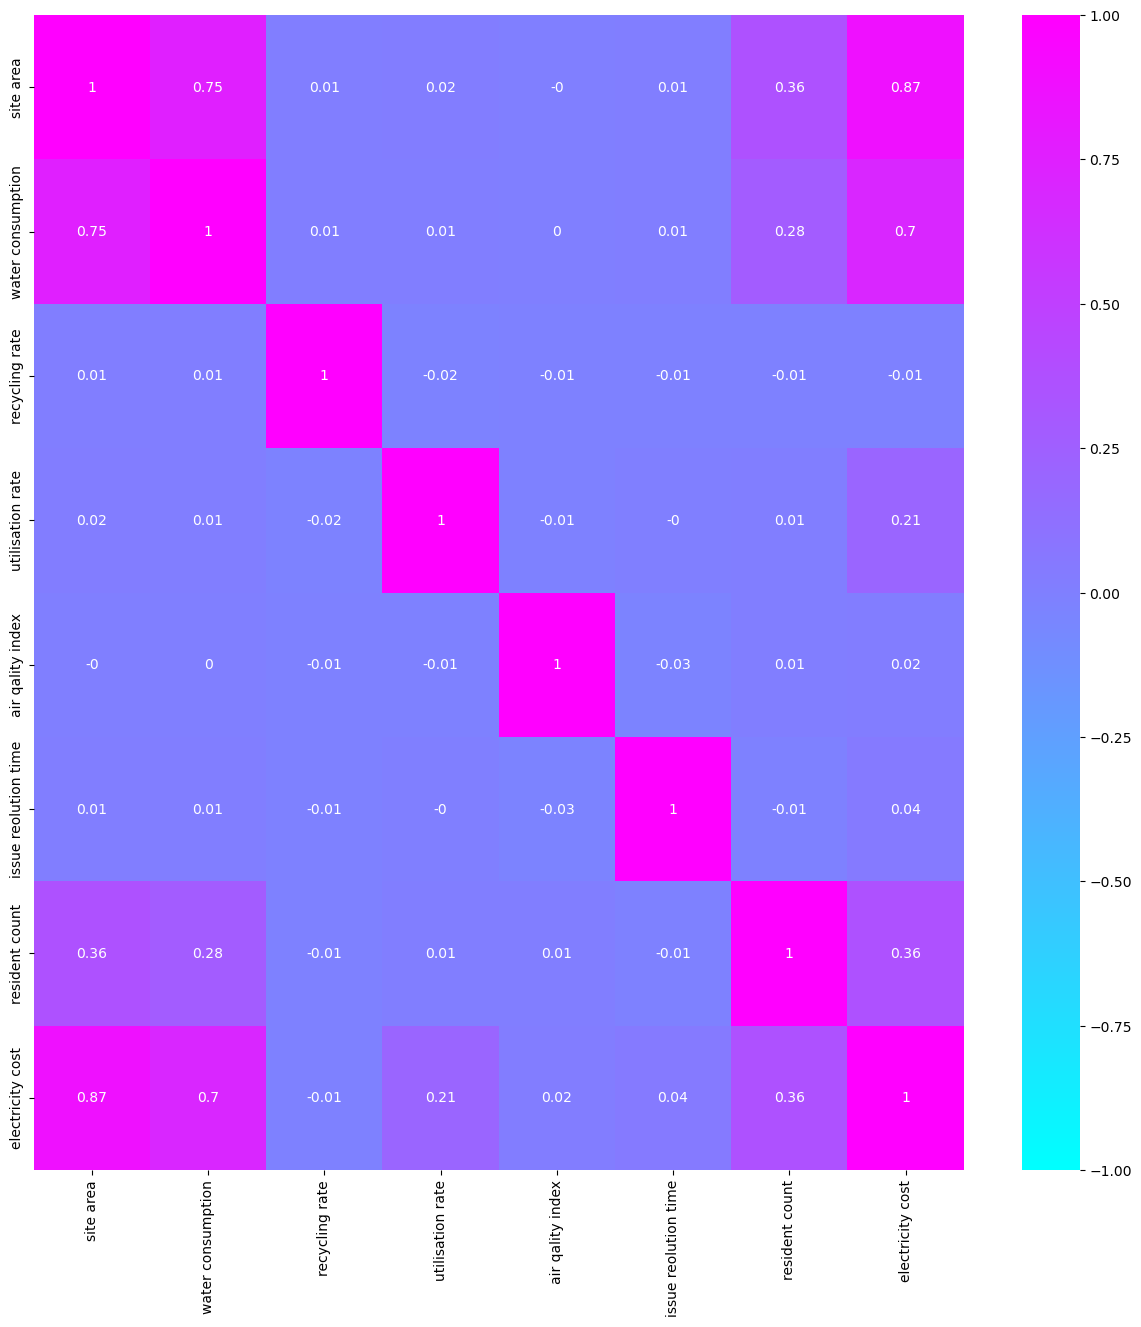

In [97]:
corr_electricity = df_copy.corr(numeric_only=True).round(2)
print(corr_electricity)

# Hartă de corelare
# Crearea figurii cu dimensiunea 15x15 inch
plt.figure(figsize=(15,15))

# Crearea unui heatmap pentru matricea de corelații 'corr_boston'
sns.heatmap(
    data=corr_electricity,   # datele care vor fi afișate în heatmap
    vmin=-1,            # valoarea minimă a culorilor (pentru scală)
    vmax=1,             # valoarea maximă a culorilor (pentru scală)
    center=0,           # centrul culorilor la 0 (pozitive vs negative)
    annot=True,         # afișează valorile numerice în celule
    cmap='cool'         # paleta de culori folosită
)

# Afișarea graficului
plt.show()

Observam ca variabila electricity cost este puternic corelata pozitiv  cu site area(0.87) si water consumption (0.75) si slab corelata negativ cu recycling rate (-0.01), ceea ce arata ca suprafata totatala a site ului si consumul de apa  influenteaza costul electricitatii.Variabilele cu corelație puternică vor fi principalele predictori în model, dar vom include și alți factori (utilisation rate, Issue Resolution Time) pentru o analiză mai completă. Analizând matricea de corelație, se observă că unele variabile sunt foarte corelate între ele (|r| > 0.7), ceea ce poate provoca multicolinearitate în modelul de regresie. Pentru a evita redundanța și a crește stabilitatea coeficienților, se păstrează doar o variabilă din fiecare pereche puternic corelată și se elimină cealaltă.

 Păstrăm site area și eliminăm water consumption .

In [98]:
print("===== Date lipsă ===== ") 
df.isna().sum()

===== Date lipsă ===== 


site area               0
structure type          0
water consumption       0
recycling rate          0
utilisation rate        0
air qality index        0
issue reolution time    0
resident count          0
electricity cost        0
dtype: int64

Deoarece nu exitsa valori lipsa nu vom curata datele.

In [99]:
# Calcularea Q1, Q3 și IQR pentru MEDV
Q1 = df["electricity cost"].quantile(0.25)
Q3 = df["electricity cost"].quantile(0.75)
IQR = Q3 - Q1

# Limitele pentru outlieri
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Limita inferioară:", lower_bound)
print("Limita superioară:", upper_bound)

# Eliminarea outlierilor 
df_original= df
df = df[(df["electricity cost"] >= lower_bound) & (df["electricity cost"] <= upper_bound)]
print("Dimensiune dataset original:", df_original.shape)
print("Dimensiune dataset fără outlieri:", df.shape)

# Verificarea valorilor pentru siguranță
print("Valori maxime electricity cost după eliminare:", df["electricity cost"].max())
print("Valori minime electricity cost după eliminare:", df["electricity cost"].min())

Limita inferioară: -563.0
Limita superioară: 6149.0
Dimensiune dataset original: (10000, 9)
Dimensiune dataset fără outlieri: (9997, 9)
Valori maxime electricity cost după eliminare: 6103.0
Valori minime electricity cost după eliminare: 500.0


In [100]:
cols = 'water consumption'
nemodificat=df
df = df.drop(columns=cols)

# Verificăm dimensiunea noului dataframe
print("Dimensiunea inițială:", nemodificat.shape)
print("Dimensiunea după eliminare:", df.shape)

# Verificăm coloanele rămase
print("Coloane rămase:", df.columns.tolist())

Dimensiunea inițială: (9997, 9)
Dimensiunea după eliminare: (9997, 8)
Coloane rămase: ['site area', 'structure type', 'recycling rate', 'utilisation rate', 'air qality index', 'issue reolution time', 'resident count', 'electricity cost']


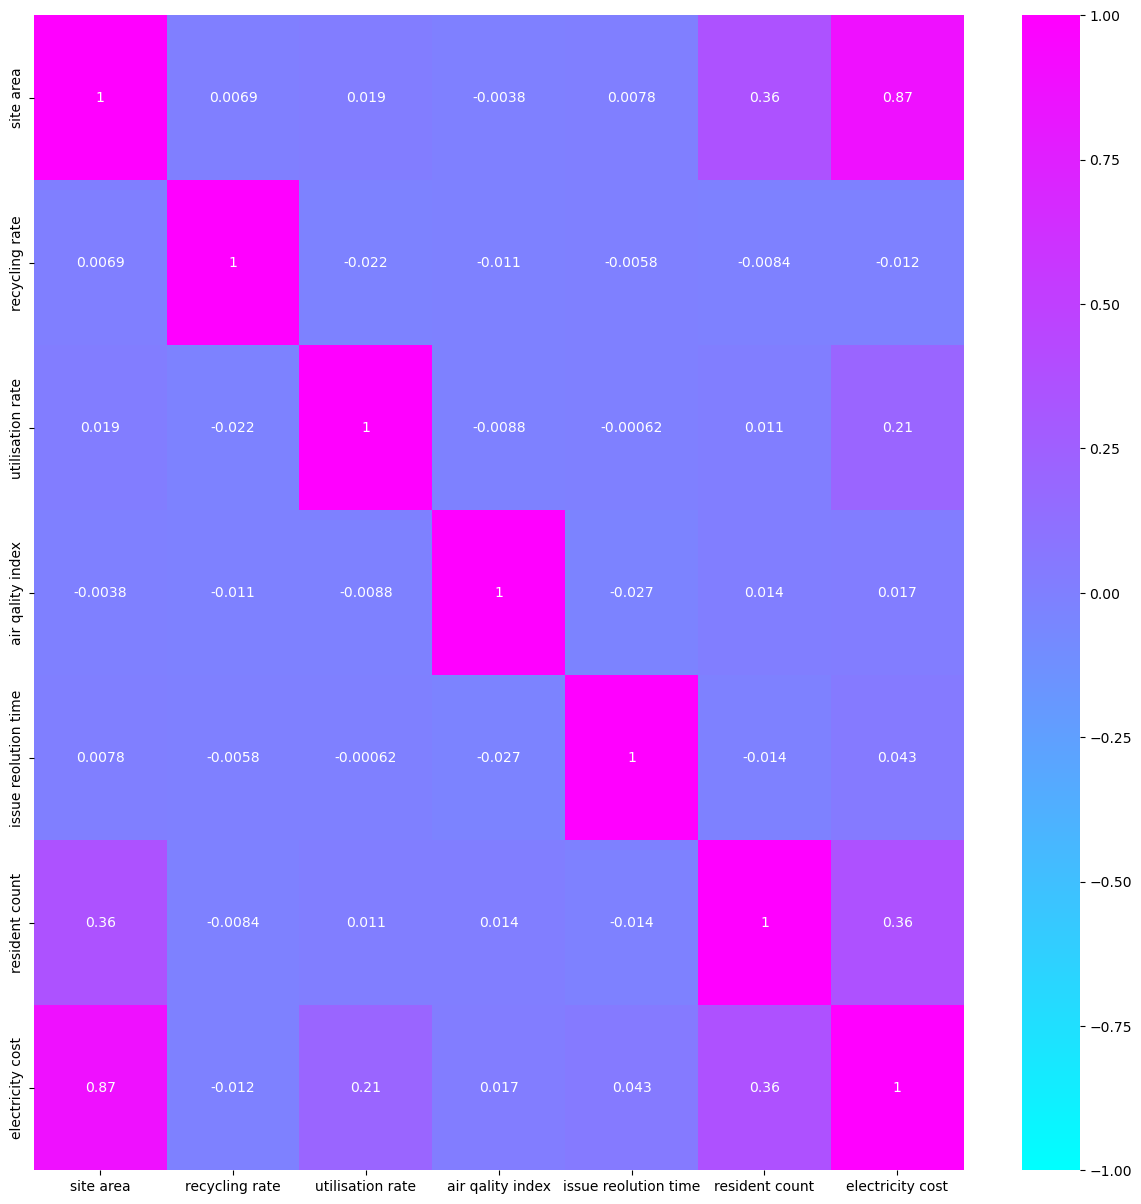

In [101]:
# Hartă de corelare
# Crearea figurii cu dimensiunea 15x15 inch
plt.figure(figsize=(15,15))
corr_electricity = df.corr(numeric_only=True)
# Crearea unui heatmap pentru matricea de corelații 'corr_boston'
sns.heatmap(
    data=corr_electricity,   # datele care vor fi afișate în heatmap
    vmin=-1,            # valoarea minimă a culorilor (pentru scală)
    vmax=1,             # valoarea maximă a culorilor (pentru scală)
    center=0,           # centrul culorilor la 0 (pozitive vs negative)
    annot=True,         # afișează valorile numerice în celule
    cmap='cool'         # paleta de culori folosită
)

# Afișarea graficului
plt.show()

In [102]:
df

,site area,structure type,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,Mixed-use,69,52,188,1,72,1420.0
1,4272,Mixed-use,50,76,165,65,261,3298.0
2,3592,Mixed-use,20,94,198,39,117,3115.0
3,966,Residential,13,60,74,3,35,1575.0
4,4926,Residential,23,65,32,57,185,4301.0
...,...,...,...,...,...,...,...,...
9995,708,Commercial,76,77,22,23,0,885.0
9996,2960,Residential,22,72,100,47,54,3081.0
9997,3942,Commercial,61,43,48,49,0,3325.0
9998,3211,Commercial,72,73,105,55,0,2892.0


In [103]:
# Selectarea coloanelor categorice pentru one-hot encoding
categorical_cols =['structure type']
from sklearn.preprocessing import OneHotEncoder

# Crearea encoder-ului
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' evită colinearitatea

# Aplicarea encoding-ului
encoded = encoder.fit_transform(df[categorical_cols])

# Obținerea de nume noi pentru coloane
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Crearea DataFrame-ului cu coloanele one-hot
df_encoded = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)

# Eliminarea coloanelor originale și concatenarea celor one-hot
df_modificat = pd.concat([df.drop(columns=categorical_cols), df_encoded], axis=1)

df_modificat.head()

,site area,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost,structure type_Industrial,structure type_Mixed-use,structure type_Residential
0,1360,69,52,188,1,72,1420.0,0.0,1.0,0.0
1,4272,50,76,165,65,261,3298.0,0.0,1.0,0.0
2,3592,20,94,198,39,117,3115.0,0.0,1.0,0.0
3,966,13,60,74,3,35,1575.0,0.0,0.0,1.0
4,4926,23,65,32,57,185,4301.0,0.0,0.0,1.0


In [104]:
df_modificat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9997 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   site area                   9997 non-null   int64  
 1   recycling rate              9997 non-null   int64  
 2   utilisation rate            9997 non-null   int64  
 3   air qality index            9997 non-null   int64  
 4   issue reolution time        9997 non-null   int64  
 5   resident count              9997 non-null   int64  
 6   electricity cost            9997 non-null   float64
 7   structure type_Industrial   9997 non-null   float64
 8   structure type_Mixed-use    9997 non-null   float64
 9   structure type_Residential  9997 non-null   float64
dtypes: float64(4), int64(6)
memory usage: 859.1 KB


In [105]:
df_modificat.shape

(9997, 10)

In [106]:
# Variabila țintă (valoarea locuinței)
y = df_modificat['electricity cost']
y.head()

0    1420.0
1    3298.0
2    3115.0
3    1575.0
4    4301.0
Name: electricity cost, dtype: float64

In [110]:
# Variabila independentă
X1 = df_modificat[['site area']]
X1.head()

,site area
0,1360
1,4272
2,3592
3,966
4,4926


In [111]:
# Creare date de antrenare și de testare
from sklearn.model_selection import train_test_split

# Împărțirea datelor în set de antrenare și testare
X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=42)

print("Dimensiune set antrenare:", X1_train.shape, y_train.shape)
print("Dimensiune set test:", X1_test.shape, y_test.shape)

Dimensiune set antrenare: (7997, 1) (7997,)
Dimensiune set test: (2000, 1) (2000,)


In [112]:
from sklearn.linear_model import LinearRegression

# Crearea modelului
housing_model1 = LinearRegression()
# Antrenarea modelului pe datele de antrenare
housing_model1.fit(X1_train, y_train)

LinearRegression()

In [113]:
print("Coeficienți:", housing_model1.coef_) #coeficientul pentru variabila RM.
print("Intercept:", housing_model1.intercept_) #termenul liber din ecuația de regresie.

Coeficienți: [0.74828191]
Intercept: 775.4975743558762


In [114]:
# Prezicerea valorilor pentru setul de test
price_pred1 = housing_model1.predict(X1_test)
r2_1 = housing_model1.score(X1_test, y_test)
print('R-square: %.4f' % r2_1 )

R-square: 0.7635


In [115]:
# Evaluarea performanței modelului
from sklearn.metrics import mean_squared_error
import numpy as np

MSE1 = mean_squared_error( y_test, price_pred1)
print("MSE:", MSE1)

RMSE1 = np.sqrt(MSE1)
print("RMSE:", RMSE1)

MSE: 291830.6158078562
RMSE: 540.2134909532122


In [122]:
# Variabile independente
X2 = df_modificat[['site area', 'resident count', 'utilisation rate']]
X2.head()

,site area,resident count,utilisation rate
0,1360,72,52
1,4272,261,76
2,3592,117,94
3,966,35,60
4,4926,185,65


In [123]:
# Creare date de antrenare și de testare
# Împărțirea datelor în set de antrenare și testare
X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42)

print("Dimensiune set antrenare:", X2_train.shape, y_train.shape)
print("Dimensiune set test:", X2_test.shape, y_test.shape)

Dimensiune set antrenare: (7997, 3) (7997,)
Dimensiune set test: (2000, 3) (2000,)


In [124]:
# Crearea modelului
housing_model2 = LinearRegression()
# Antrenarea modelului pe datele de antrenare
housing_model2.fit(X2_train, y_train)

LinearRegression()

In [125]:
print("Coeficienți:", housing_model2.coef_) #coeficienții pentru variabilele LSTAT și RM.
print("Intercept:", housing_model2.intercept_) #termenul liber din ecuația de regresie.

Coeficienți: [ 0.73015831  0.50830035 10.31356523]
Intercept: 113.59850885022342


In [126]:
# Prezicerea valorilor pentru setul de test
price_pred2 = housing_model2.predict(X2_test)
r2_2=housing_model2.score(X2_test, y_test)
print('R-square: %.4f' % r2_2)

R-square: 0.8000


In [127]:
# Evaluarea performanțelor modelului
from sklearn.metrics import mean_squared_error
import numpy as np

MSE2 = mean_squared_error( y_test, price_pred2)
print("MSE:", MSE2)

RMSE2 = np.sqrt(MSE2)
print("RMSE:", RMSE2)

MSE: 246756.537433672
RMSE: 496.74594858304783


Modelul de regresie liniară cu două variabile a obținut un coeficient  𝑅2
  de 0.8000, ceea ce indică faptul că aproximativ 80% din variația prețurilor electricitatii este explicată de variabilele incluse.
  O data cu introducerea tuturor variabilelor R^2 va creste, deci modelul a fost imbunatatit.

In [130]:
# Prezicerea valorilor pentru setul de test
price_pred2 = housing_model2.predict(X2_test)
r2_2=housing_model2.score(X2_test, y_test)
print('R-square: %.4f' % r2_2)

R-square: 0.8000


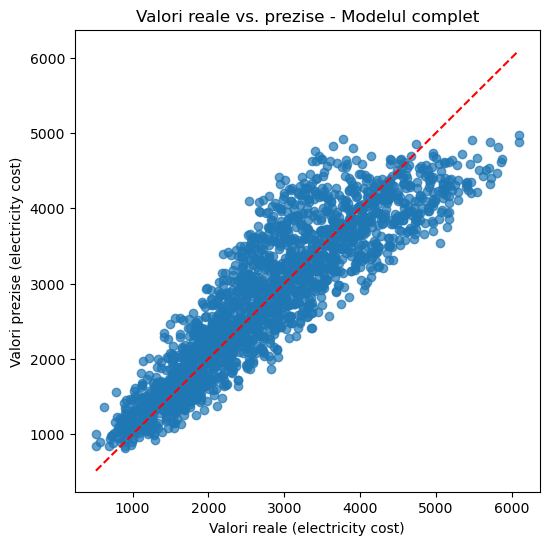

In [131]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, price_pred2, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Valori reale (electricity cost)")
plt.ylabel("Valori prezise (electricity cost)")
plt.title("Valori reale vs. prezise - Modelul complet")
plt.show()

Modelul de regresie liniara  multipla ofera cea mai buna estimare a costului energiei electrice pe baza caracteristicilor disponibile.Includerea tuturor predictorilor va imbunatati semnificativ performanata.